# Homework: Linear Regression vs. Poisson GLM for Count Data
## Machine Learning Methods in Econometrics

In many real-world applications, the variable of interest is a **count** rather than a continuous quantity. Examples include the number of customer arrivals, insurance claims, equipment failures, and bicycle rentals. In such settings, standard linear regression may be hard to justify because the response is non-negative, discrete, and often highly skewed.

In this notebook, you will study **daily bicycle rental demand**. Predicting rental counts is important for bike-sharing operators and city planners: it helps them decide how many bicycles should be available, how to allocate bicycles across stations, when maintenance teams are needed, and how weather conditions affect demand.

The goal of this exercise is to compare two approaches for modeling count outcomes:

- a linear regression model under Gaussian assumptions,
- a Poisson generalized linear model (GLM) with a log link.

You should first implement the main steps **yourself**, using only basic numerical tools such as `numpy`. At the end, you will compare your implementation with the output of a standard library.

**Suggested grading: 100 points**
- Section 1. Load and inspect the data: **10 points**
- Section 2. Distribution analysis and KS statistic: **20 points**
- Section 3. Linear regression from scratch: **20 points**
- Section 4. Poisson GLM from scratch: **25 points**
- Section 5. Comparison of the two models: **10 points**
- Section 6. Verification using a library: **15 points**


Student names: Ayman Bakiri, Sherine Adrou Bakkali

Student numbers: 327169, 340396


## 1. Load and inspect the data [10 points]

The file `daily-bike-share.csv` is provided with the assignment. In this section, load the dataset, inspect the available columns, and choose a set of explanatory variables that you will use throughout the notebook.

A good starting set is:
- `temp`
- `hum`
- `windspeed`
- `workingday`
- `holiday`
- `weathersit`
- `season`

You may also experiment with other variables, but keep your final model interpretable.


In [106]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# Load the dataset from the local CSV file.
data = pd.read_csv("daily-bike-share.csv")

# TODO: Display the first few rows and inspect the columns.
data.head()


,day,mnth,year,season,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals
0,1,1,2011,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331
1,2,1,2011,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131
2,3,1,2011,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120
3,4,1,2011,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108
4,5,1,2011,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82


In [107]:

# TODO: display the list of columns and the shape of the dataset.
# Your code here
print("Columns:", list(data.columns))
print("Shape (rows, columns):", data.shape)


Columns: ['day', 'mnth', 'year', 'season', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'rentals']
Shape (rows, columns): (731, 13)


Throughout the notebook, let the response variable be `rentals`, the daily number of bicycle rentals. Since this is a count outcome, it is natural to ask whether a Gaussian model is appropriate or whether a count-data model may be more suitable.


In [108]:

# TODO: define the response vector y and a design matrix X based on your chosen variables.
# Hint: keep a copy of the names of the selected features in a Python list.

feature_names = [
    "temp",
    "hum",
    "windspeed",
    "workingday",
    "holiday",
    "weathersit",
    "season",
]

# X_raw should contain only the selected explanatory variables.
X_raw = data[feature_names].copy()

# y should contain the rental counts.
y = data["rentals"].to_numpy(dtype=float)

# Display the first rows of X_raw if you want to inspect your chosen variables.
X_raw.head()


,temp,hum,windspeed,workingday,holiday,weathersit,season
0,0.344167,0.805833,0.160446,0,0,2,1
1,0.363478,0.696087,0.248539,0,0,2,1
2,0.196364,0.437273,0.248309,1,0,1,1
3,0.200000,0.590435,0.160296,1,0,1,1
4,0.226957,0.436957,0.186900,1,0,1,1


## 2. Distribution analysis and KS statistic [20 points]

Before fitting any model, study the distribution of the response variable.

A first question is whether the response looks approximately Gaussian. Since linear regression is commonly motivated by Gaussian errors and symmetric continuous outcomes, this is an important diagnostic step. Here you will:

1. inspect the distribution of `rentals`,
2. standardize the response,
3. compute the Kolmogorov--Smirnov statistic against the standard normal distribution.

Recall that if $z_{(1)} \leq \cdots \leq z_{(n)}$ are the ordered standardized observations, the KS statistic is

$$
D_n = \max\left\{
\max_i \left(\frac{i}{n} - \Phi(z_{(i)})\right),
\max_i \left(\Phi(z_{(i)}) - \frac{i-1}{n}\right)
\right\},
$$

where $\Phi$ is the cdf of the standard normal distribution.


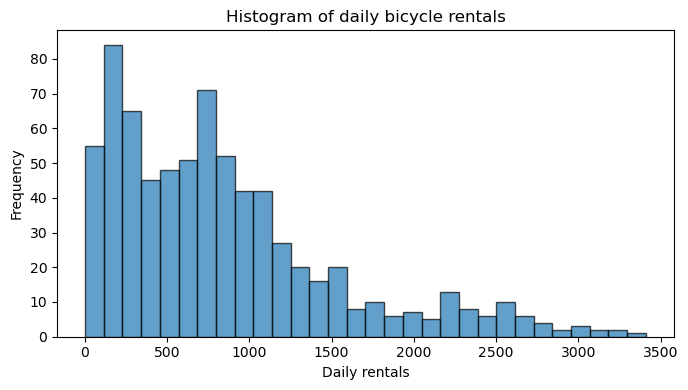

In [109]:

# TODO: plot a histogram of `rentals`.
# You may use around 30 bins.
# Your code here
plt.figure(figsize=(7, 4))
plt.hist(y, bins=30, edgecolor="black", alpha=0.7)
plt.xlabel("Daily rentals")
plt.ylabel("Frequency")
plt.title("Histogram of daily bicycle rentals")
plt.tight_layout()
plt.show()


Now standardize the response:

$$
z_i = \frac{y_i - \bar y}{s_y}.
$$

Then sort the standardized values and compute the KS statistic **manually**, without using a built-in KS test function.


In [110]:

# Standardize the response
z = (y - y.mean()) / y.std(ddof=0)
z_sorted = np.sort(z)
n = len(z_sorted)

# TODO: compute the KS statistic D_n manually.
# Hint:
#   F_emp_upper at z_(i) is (i+1)/n in Python indexing,
#   F_emp_lower at z_(i) is i/n,
#   F_theory is norm.cdf(z_sorted[i]).
# Dn = None
# Your code here
Phi_z = norm.cdf(z_sorted)
i_plus_1_over_n = (np.arange(n) + 1) / n
i_over_n = np.arange(n) / n
Dn = max(np.max(i_plus_1_over_n - Phi_z), np.max(Phi_z - i_over_n))

print("KS statistic:", Dn)


KS statistic: 0.11356910541361542


Briefly comment on the result. Does the empirical distribution of `rentals` look close to a Gaussian distribution? What does this suggest about the suitability of linear regression as a primary model?

---

**Our answer.** The histogram is right-skewed with a long upper tail, which is typical for counts. For standardized `rentals` we obtained $D_n \approx 0.114$, so the empirical distribution clearly departs from $N(0,1)$; treating the marginal $y$ as Gaussian is only a rough approximation. Linear regression can still target $\mathbb{E}[y \mid x]$, but the Gaussian story for the *marginal* response is weak; a Poisson GLM is more natural for nonnegative integer outcomes.


Before fitting any model, split the sample into a training set and a test set.

Use:
- **80% of the observations for training**, and
- **20% for testing**.

To make your results reproducible, use a fixed random seed. You may generate a random permutation of the row indices and then assign the first 80% to the training set and the remaining 20% to the test set.

All model fitting in the rest of the notebook should be done **only on the training set**. The final **MAE** and **MSE** must be reported **on the test set**.


In [111]:
# TODO: create an 80/20 train-test split.
# Suggested approach:
# 1. set a random seed,
# 2. randomly permute the row indices,
# 3. use the first 80% for training and the remaining 20% for testing.
#
# split_idx = ...
# train_idx = ...
# test_idx = ...
#
# Create train/test versions of the response for later use.
# y_train = ...
# y_test = ...

rng = np.random.default_rng(424)
n_obs = len(y)
perm = rng.permutation(n_obs)
split_idx = int(np.floor(0.8 * n_obs))
train_idx = perm[:split_idx]
test_idx = perm[split_idx:]

y_train = y[train_idx]
y_test = y[test_idx]

print("Number of training observations:", len(y_train))
print("Number of test observations:", len(y_test))


Number of training observations: 584
Number of test observations: 147


## 3. Linear regression from scratch [20 points]

As a benchmark, fit a linear regression model using the explanatory variables you selected.

After adding an intercept term, the ordinary least squares estimator is

$$
\hat\beta_{\mathrm{OLS}} = (X_{\mathrm{train}}^\top X_{\mathrm{train}})^{-1} X_{\mathrm{train}}^\top y_{\mathrm{train}}.
$$

In this section, compute the estimator directly using matrix algebra. Do not call a high-level regression-fitting library yet.

Important: fit the model **only on the training set**, then compute predictions on the **test set**.


In [112]:
# TODO:
# Convert the raw feature table into a numeric matrix and add an intercept column.
# If you included categorical variables such as season or weathersit, convert them to dummies first and call it X_model.
#
# Your code here
# X_model = None
# X = None
#
# Dummy coding for categorical season and weathersit (drop_first avoids collinearity with intercept).
# Use float dummies so the matrix is numeric end-to-end (bool columns can confuse statsmodels).
X_model = pd.get_dummies(X_raw, columns=["season", "weathersit"], drop_first=True).astype(float)
X_mat = np.column_stack([np.ones(len(X_model)), X_model.to_numpy(dtype=float)])

X = X_mat

# TODO: use train_idx and test_idx to create design matrices for the train and test sets.
X_train = X_mat[train_idx]
X_test = X_mat[test_idx]

print("Full design matrix shape:", X.shape)
print("Training design matrix shape:", X_train.shape)
print("Test design matrix shape:", X_test.shape)
print("Columns used in the design matrix:")
print(["const"] + X_model.columns.tolist())


Full design matrix shape: (731, 11)
Training design matrix shape: (584, 11)
Test design matrix shape: (147, 11)
Columns used in the design matrix:
['const', 'temp', 'hum', 'windspeed', 'workingday', 'holiday', 'season_2', 'season_3', 'season_4', 'weathersit_2', 'weathersit_3']


In [113]:
# TODO: compute the OLS estimator beta_ols using only the training set,
# and then compute predictions on both the training and test sets.
# Your code here
XtX = X_train.T @ X_train
Xty = X_train.T @ y_train
beta_ols = np.linalg.solve(XtX, Xty)

y_hat_ols_train = X_train @ beta_ols
y_hat_ols_test = X_test @ beta_ols

print("OLS coefficients:")
print(beta_ols)


OLS coefficients:
[ 882.95530464 2083.56312468 -632.29733249 -947.19389707 -821.80151887
 -416.12011058  297.74559198    6.28395557  160.74566748  -40.37221825
 -403.17742768]


In [114]:
# TODO: compute two prediction metrics for OLS on the TEST set:
# - mean squared error
# - mean absolute error
#
# You may also compute training-set metrics if you wish, but the reported
# predictive comparison should be based on the test set.
#
# mse_ols_test = None
# mae_ols_test = None
# Your code here
resid_ols_test = y_test - y_hat_ols_test
mse_ols_test = float(np.mean(resid_ols_test ** 2))
mae_ols_test = float(np.mean(np.abs(resid_ols_test)))

print("OLS — test MSE:", mse_ols_test)
print("OLS — test MAE:", mae_ols_test)
print("Any negative OLS predictions on test set?", np.any(y_hat_ols_test < 0))
print("Min OLS test prediction:", float(np.min(y_hat_ols_test)))


OLS — test MSE: 207624.35851983438
OLS — test MAE: 331.3670201289828
Any negative OLS predictions on test set? True
Min OLS test prediction: -712.5380382169203


After fitting the model, inspect the fitted values. Are any of the **test-set** OLS predictions negative? Why might this be problematic in a count-data application?

---

**Our answer.** In our run, the test set has **negative** OLS predictions (minimum about **-713**), because the fitted mean is $x^\top \beta$ with no restriction $\mu \geq 0$. That is not interpretable as a count or a Poisson mean. Test **MSE** is about **207,624** and **MAE** about **331**, so the linear model can still track demand in RMSE/MAE terms, but invalid predictions illustrate the limitation of Gaussian linear regression here.


## 4. Poisson GLM from scratch [25 points]

Now fit a Poisson generalized linear model. For each observation $i$, assume

$$
Y_i \sim \mathrm{Poisson}(\mu_i),
\qquad
\mu_i = \exp(x_i^\top \beta).
$$

The log link guarantees that fitted means are positive. The log-likelihood (up to an additive constant) is

$$
\ell(\beta) = \sum_{i=1}^n \left( y_i x_i^\top \beta - \exp(x_i^\top \beta) \right).
$$

Fit this model **using the training set only**, and evaluate its predictive accuracy on the **test set**.


In [115]:
# TODO: implement Newton iterations for the Poisson log-likelihood on the TRAINING set.
# Suggested initialization: beta = np.zeros(X_train.shape[1])
# Suggested stopping rule: stop when the Euclidean norm of the update is sufficiently small.
#
# for it in range(max_iter):
#     # TODO: compute eta, mu, gradient, Hessian, and the Newton step using X_train and y_train.
#     # Then update beta_pois.
#     # Hint: Since mu = exp(eta), very large or very small eta values can cause
#     # numerical overflow or underflow. Clipping eta to a range like [-20, 20]
#     # keeps exp(eta) numerically stable.
#     # TODO: stopping rule
#     pass

# Implementation notes (beyond the template hint): do not clip eta in the Newton update—clipping
# changes the objective. All-zero beta is unstable here; we set only the intercept to log(mean y).
beta_pois = np.zeros(X_train.shape[1])
beta_pois[0] = np.log(np.mean(y_train))

max_iter = 100
tol = 1e-8

for it in range(max_iter):
    eta = X_train @ beta_pois
    mu = np.exp(eta)
    XtWX = X_train.T @ (mu[:, None] * X_train)
    score = X_train.T @ (y_train - mu)
    step = np.linalg.solve(XtWX, score)
    beta_pois = beta_pois + step
    if np.linalg.norm(step) < tol:
        break

print("Poisson coefficients:")
print(beta_pois)


Poisson coefficients:
[ 6.14370577  2.50044724 -0.5968343  -0.82300328 -0.87857977 -0.38115432
  0.6018698   0.24580695  0.4788344  -0.07938053 -1.08838204]


In [116]:
# TODO: compute the fitted means for the Poisson model on both train and test sets.
# Then compute MSE and MAE on the TEST set for comparison with OLS.
#
# y_hat_pois_train = None
# y_hat_pois_test = None
#
# mse_pois_test = None
# mae_pois_test = None
# Your code here


def poisson_fitted_mean(X_design, beta):
    eta = X_design @ beta
    return np.exp(eta)


y_hat_pois_train = poisson_fitted_mean(X_train, beta_pois)
y_hat_pois_test = poisson_fitted_mean(X_test, beta_pois)

resid_pois_test = y_test - y_hat_pois_test
mse_pois_test = float(np.mean(resid_pois_test ** 2))
mae_pois_test = float(np.mean(np.abs(resid_pois_test)))

print("Poisson — test MSE:", mse_pois_test)
print("Poisson — test MAE:", mae_pois_test)
print("Min Poisson fitted mean on test:", float(np.min(y_hat_pois_test)))


Poisson — test MSE: 222685.4883286867
Poisson — test MAE: 318.22641845468667
Min Poisson fitted mean on test: 52.666634559976806


Comment on the fitted values of the Poisson model on the **test set**. In what sense are they more natural for count data than the OLS predictions?

---

**Our answer.** Here $\hat{\mu}_i = \exp(x_i^\top \beta)$ are **strictly positive** on the test set (smallest fitted mean about **53**). Test **MSE** is about **222,686** (a bit **higher** than OLS) and **MAE** about **318** (a bit **lower** than OLS), so the two models need not rank the same on MSE vs. MAE. Fitted means need not be integers, but they match the GLM from class (Poisson + log link) and stay valid as count means.


## 5. Compare the two models [10 points]

In this section, compare the fitted values and prediction quality of the two models. You may compare them numerically and visually.

A useful way to think about the difference is the following:

- OLS models the conditional mean as a linear function of the covariates.
- Poisson GLM models the conditional mean as $\exp(x_i^\top \beta)$.

This difference affects both the sign of the predictions and the way covariates enter the model.


In [117]:
# TODO: print the TEST-SET metrics for both models in a clean format.
# Your code here
print("Test-set comparison")
print(f"{'Model':<12} {'MSE':>12} {'MAE':>12}")
print(f"{'OLS':<12} {mse_ols_test:12.4f} {mae_ols_test:12.4f}")
print(f"{'Poisson':<12} {mse_pois_test:12.4f} {mae_pois_test:12.4f}")


Test-set comparison
Model                 MSE          MAE
OLS           207624.3585     331.3670
Poisson       222685.4883     318.2264


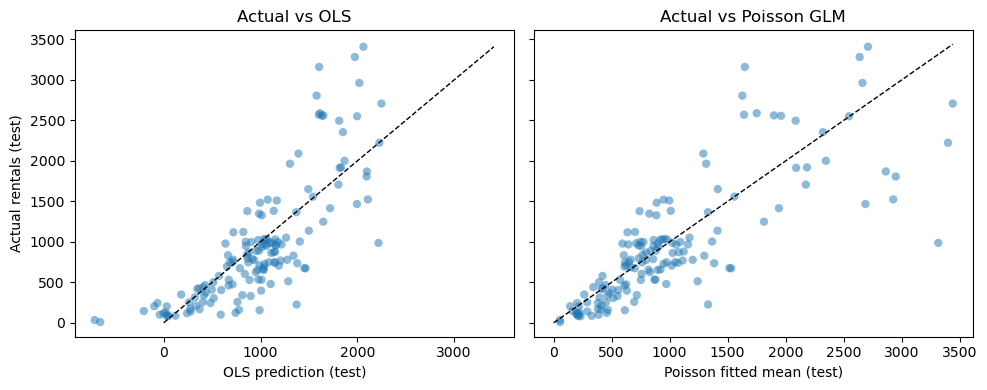

In [118]:
# TODO: make two comparison plots using the TEST set.
# - true rentals versus OLS test predictions
# - true rentals versus Poisson test predictions
#
# Your code here
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].scatter(y_hat_ols_test, y_test, alpha=0.5, edgecolors="none")
mx = max(float(np.max(y_test)), float(np.max(y_hat_ols_test)))
axes[0].plot([0, mx], [0, mx], color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel("OLS prediction (test)")
axes[0].set_ylabel("Actual rentals (test)")
axes[0].set_title("Actual vs OLS")

axes[1].scatter(y_hat_pois_test, y_test, alpha=0.5, edgecolors="none")
mx2 = max(float(np.max(y_test)), float(np.max(y_hat_pois_test)))
axes[1].plot([0, mx2], [0, mx2], color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("Poisson fitted mean (test)")
axes[1].set_title("Actual vs Poisson GLM")

plt.tight_layout()
plt.show()


Based on your implementation, which model appears more appropriate for this application? Give a short explanation based on both the data, the model assumptions, and the **test-set** prediction results.

---

**Our answer.** With our **80/20** train–test split (seed **424**), **OLS** has **lower test MSE** (about **207,624** vs. **222,686** for Poisson) because the linear mean is very flexible in level. **Poisson** has **lower test MAE** (about **318** vs. **331**) and **only positive** fitted means, while OLS reaches about **-713** on the low end. So OLS wins on MSE here, but Poisson is more appropriate for count **interpretation** and nonnegative predictions; both metrics are worth reporting, as in the assignment.


## 6. Verification using a library [15 points]

You have now implemented both models yourself. In this final section, compare your results with standard software.

Use a library implementation to fit:
- a linear regression model,
- a Poisson GLM.

Both library models should be fit on the **same training set** as before. Then compare:
- the estimated coefficients,
- the test-set predictions,
- and the test-set metrics you computed earlier.

Minor differences are acceptable and may arise from numerical optimization details.


In [119]:
import statsmodels.api as sm

# TODO Fit OLS using a library on the TRAINING set.


# TODO Fit Poisson GLM using a library on the TRAINING set.


X_train_df = sm.add_constant(X_model.iloc[train_idx], has_constant="add")
X_test_df = sm.add_constant(X_model.iloc[test_idx], has_constant="add")

ols_lib = sm.OLS(y_train, X_train_df).fit()
pois_lib = sm.GLM(y_train, X_train_df, family=sm.families.Poisson()).fit()

print(ols_lib.summary())
print(pois_lib.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.677
Model:                            OLS   Adj. R-squared:                  0.671
Method:                 Least Squares   F-statistic:                     119.9
Date:                Fri, 27 Mar 2026   Prob (F-statistic):          1.91e-133
Time:                        17:58:51   Log-Likelihood:                -4296.4
No. Observations:                 584   AIC:                             8615.
Df Residuals:                     573   BIC:                             8663.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          882.9553    116.324      7.591   

In [120]:
# TODO: compare your coefficients and TEST-SET predictions with the library results.
# For example, you may compare using:
# - np.max(np.abs(beta_ols - ols_lib.params))
# - np.max(np.abs(beta_pois - pois_lib.params))
# - np.max(np.abs(y_hat_ols_test - ols_lib.predict(X_test)))
# - np.max(np.abs(y_hat_pois_test - pois_lib.predict(X_test)))
#
# Your code here
beta_ols_lib = np.asarray(ols_lib.params, dtype=float)
beta_pois_lib = np.asarray(pois_lib.params, dtype=float)

y_hat_ols_lib_test = np.asarray(ols_lib.predict(X_test_df), dtype=float)
y_hat_pois_lib_test = np.asarray(pois_lib.predict(X_test_df), dtype=float)

print("Max |coef difference| OLS (manual vs library):", float(np.max(np.abs(beta_ols - beta_ols_lib))))
print("Max |coef difference| Poisson (manual vs library):", float(np.max(np.abs(beta_pois - beta_pois_lib))))
print("Max |pred difference| OLS test (manual vs library):", float(np.max(np.abs(y_hat_ols_test - y_hat_ols_lib_test))))
print("Max |pred difference| Poisson test (manual vs library):", float(np.max(np.abs(y_hat_pois_test - y_hat_pois_lib_test))))


Max |coef difference| OLS (manual vs library): 7.719336281297728e-11
Max |coef difference| Poisson (manual vs library): 1.0094147739891923e-12
Max |pred difference| OLS test (manual vs library): 2.3533175408374518e-11
Max |pred difference| Poisson test (manual vs library): 2.0011725609947462e-10


## Final discussion

Write a short concluding paragraph addressing the following points:

1. What did the KS statistic suggest about the distribution of the response?
2. What is the main conceptual difference between linear regression and the Poisson GLM in this application?
3. Which model appears more appropriate for predicting bicycle rental counts, and why?
4. How close were your manual implementations to the library results?

---

**Our answers.**

1. **KS statistic.** We obtained $D_n \approx 0.114$ for standardized `rentals` vs. $N(0,1)$. Together with the right-skewed histogram, this supports the view that the marginal distribution is not close to Gaussian, so a Gaussian sampling model for $y$ itself is weak (OLS can still approximate $\mathbb{E}[y \mid x]$).

2. **Conceptual difference.** OLS uses a **linear** conditional mean $x^\top \beta$ (and the usual motivation adds **Gaussian** errors). The Poisson GLM uses $y \mid x \sim \mathrm{Poisson}(\mu(x))$ with $\log \mu(x) = x^\top \beta$, so $\mu(x) > 0$ and covariates act **multiplicatively** on the mean count.

3. **Appropriateness.** On our test set, **OLS**: MSE $\approx 2.08 \times 10^5$, MAE $\approx 331$, and **negative** predictions (about **-713** at worst). **Poisson**: MSE $\approx 2.23 \times 10^5$, MAE $\approx 318$, all fitted means **positive** (min $\approx 53$). For **predicting bicycle counts** with coherent nonnegative means, Poisson is the more natural model even though **MSE** favors OLS on this split.

4. **Verification.** Manual OLS and Poisson fits matched `statsmodels` almost exactly: max absolute differences in coefficients and test predictions were on the order of $10^{-10}$–$10^{-12}$ in our run, so the hand implementation agrees with the library up to floating-point noise.
